# Trabajo Práctico Integrador – Entrega 3

**Materia:** Introducción al Análisis de Datos  
**Tema:** Cancelación de reservas hoteleras  
**Comisión:** 10 (Grupo J)  
**Integrante:** Viruel, Nicolás  
**Entrega:** 3 – Unidad N° 3 · Visualización de datos  
**Lenguaje:** Python  
**Dataset:** `hotel_booking_TPI_grupo_J.csv`  
**Variable objetivo:** `is_canceled`  
**Año:** 2026

> Notebook independiente y reproducible desde cero.

## 1. Contexto

En esta entrega aplicamos **visualización e interpretación** al dataset de reservas hoteleras. El foco no es la cantidad de gráficos, sino responder preguntas concretas sobre la **cancelación de reservas** (`is_canceled`).

## 2. Carga del dataset y preparación mínima

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../datos')
df = pd.read_csv(DATA_DIR / 'hotel_booking_TPI_grupo_J.csv')
print('Dataset cargado:', df.shape)

Dataset cargado: (25000, 32)


In [2]:
# Preparación mínima para visualizar
df['is_canceled_label'] = df['is_canceled'].map({0: 'No cancelada', 1: 'Cancelada'})
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'].fillna(0) + df['babies']

# lead_time en categorías interpretables (sin imputar children como 0 en el análisis global)
df['lead_time_segment'] = pd.cut(
    df['lead_time'],
    bins=[-1, 7, 30, 90, df['lead_time'].max()],
    labels=['0-7 días', '8-30 días', '31-90 días', '91+ días'],
)

df[['hotel', 'is_canceled', 'lead_time', 'total_nights', 'adr']].head()

,hotel,is_canceled,lead_time,total_nights,adr
0,Resort Hotel,0,261,7,42.95
1,Resort Hotel,1,85,3,64.00
2,City Hotel,1,364,2,101.50
3,City Hotel,0,32,2,114.00
4,City Hotel,1,126,2,89.10


## 3. Visualización 1 · Cancelaciones según tipo de hotel

**Pregunta:** ¿La proporción de cancelaciones difiere entre City Hotel y Resort Hotel?

**Tipo de gráfico:** barras agrupadas con conteos absolutos. Permite comparar simultáneamente volumen de reservas y balance cancelada/no cancelada por tipo de hotel.

**Elementos visuales:** color distingue estado de cancelación; posición en eje X separa hoteles.

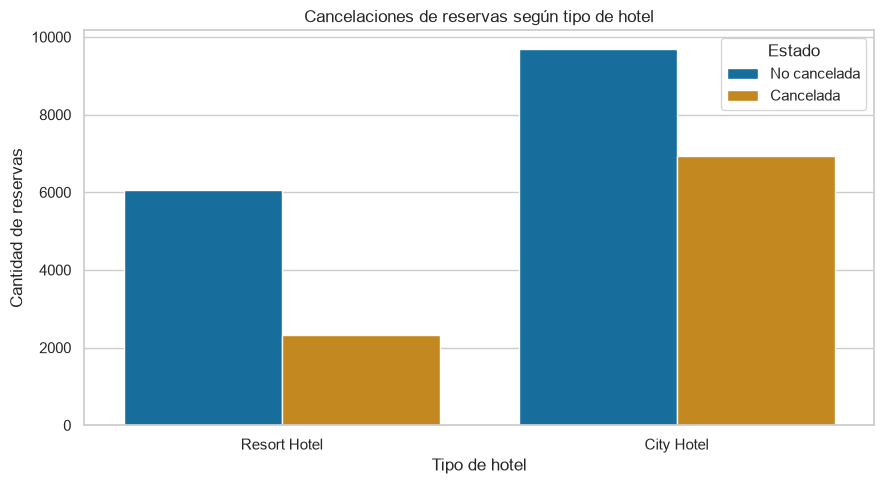

Tasa de cancelación (%):
hotel
City Hotel      41.7
Resort Hotel    27.8
Name: is_canceled, dtype: float64


In [3]:
fig, ax = plt.subplots()
sns.countplot(data=df, x='hotel', hue='is_canceled_label', ax=ax)
ax.set_title('Cancelaciones de reservas según tipo de hotel')
ax.set_xlabel('Tipo de hotel')
ax.set_ylabel('Cantidad de reservas')
ax.legend(title='Estado', loc='upper right')
plt.tight_layout()
plt.show()

tasa = df.groupby('hotel')['is_canceled'].mean().mul(100).round(1)
print('Tasa de cancelación (%):')
print(tasa)

**Interpretación:** Si la tasa de cancelación es mayor en un tipo de hotel, el patrón sugiere que el segmento (ciudad vs resort) enfrenta dinámicas distintas de reserva. Conviene contrastar con volumen absoluto: un hotel puede tener más cancelaciones totales pero menor proporción.

## 4. Visualización 2 · Variable cuantitativa y cancelación

**Pregunta:** ¿Las reservas canceladas se realizan con mayor anticipación (`lead_time`) que las no canceladas?

**Tipo de gráfico:** diagrama de cajas (boxplot) por grupo de cancelación. Resume mediana, dispersión y valores atípicos de una variable numérica frente a una binaria.

**Por qué este gráfico:** `lead_time` es continua y asimétrica; el boxplot permite comparar distribuciones sin asumir normalidad.

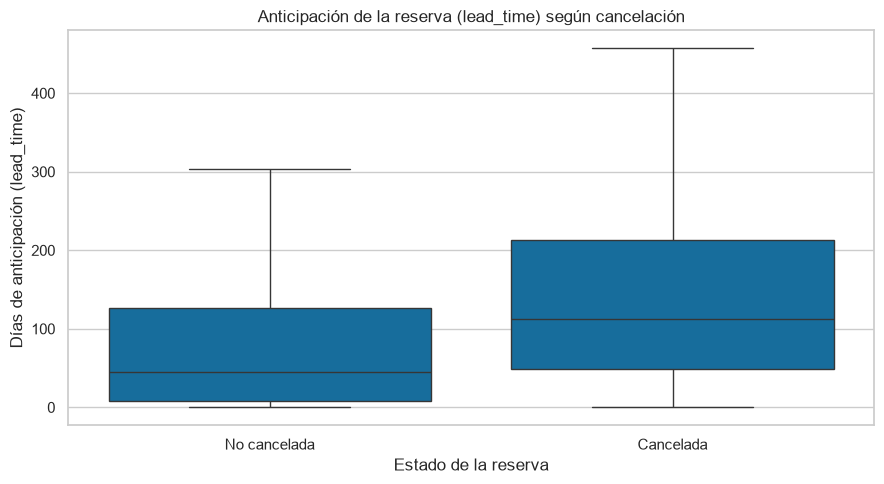

                         mean    50%    max
is_canceled_label                          
Cancelada          144.386759  113.0  629.0
No cancelada        80.598691   45.0  542.0


In [4]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='is_canceled_label', y='lead_time', ax=ax, showfliers=False)
ax.set_title('Anticipación de la reserva (lead_time) según cancelación')
ax.set_xlabel('Estado de la reserva')
ax.set_ylabel('Días de anticipación (lead_time)')
plt.tight_layout()
plt.show()

print(df.groupby('is_canceled_label')['lead_time'].describe()[['mean', '50%', 'max']])

**Interpretación:** Una mediana o media de `lead_time` más alta en canceladas indicaría que reservas muy anticipadas tienen mayor probabilidad de cancelarse (cambios de planes). Excluimos outliers del gráfico para mejorar legibilidad, pero conviene recordar que existen valores extremos que pueden influir en promedios.

## 5. Visualización 3 · Pregunta propia de análisis

**Pregunta:** ¿Cómo varía la tasa de cancelación según el tipo de depósito (`deposit_type`) y el segmento de mercado (`market_segment`)?

**Tipo de gráfico:** barras agrupadas con tasas de cancelación (%). Incorpora dos dimensiones categóricas para detectar combinaciones de mayor riesgo.

**Por qué este gráfico:** ambas variables son nominales y la respuesta es una proporción; comparar porcentajes facilita identificar políticas de depósito o canales más expuestos a cancelaciones.

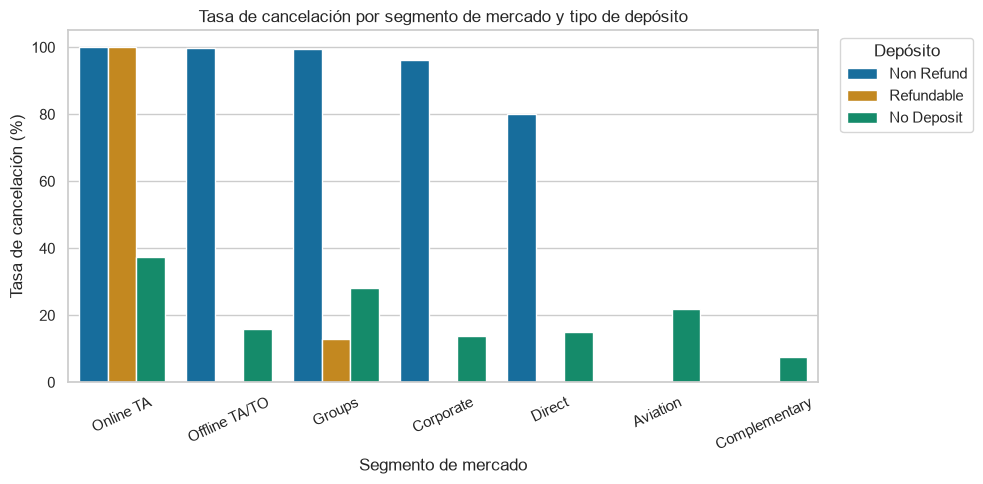

,market_segment,deposit_type,tasa_cancelacion_pct
13,Online TA,Non Refund,100.000000
14,Online TA,Refundable,100.000000
11,Offline TA/TO,Non Refund,99.904031
8,Groups,Non Refund,99.486389
3,Corporate,Non Refund,96.103896
5,Direct,Non Refund,80.000000
12,Online TA,No Deposit,37.308318
7,Groups,No Deposit,28.074989


In [5]:
tasa_dep = (
    df.groupby(['market_segment', 'deposit_type'], observed=True)['is_canceled']
    .mean()
    .mul(100)
    .reset_index(name='tasa_cancelacion_pct')
)
tasa_dep = tasa_dep.sort_values('tasa_cancelacion_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=tasa_dep,
    x='market_segment',
    y='tasa_cancelacion_pct',
    hue='deposit_type',
    ax=ax,
)
ax.set_title('Tasa de cancelación por segmento de mercado y tipo de depósito')
ax.set_xlabel('Segmento de mercado')
ax.set_ylabel('Tasa de cancelación (%)')
ax.tick_params(axis='x', rotation=25)
ax.legend(title='Depósito', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

tasa_dep.head(8)

**Interpretación:** Combinaciones con depósito no reembolsable suelen mostrar menor cancelación que reservas sin depósito, lo cual es coherente con incentivos económicos. Segmentos online/offline pueden diferir en compromiso del huésped. Hay que interpretar con cautela segmentos con pocas reservas.

## 6. Síntesis de hallazgos

1. **Tipo de hotel:** la tasa de cancelación difiere entre City Hotel y Resort Hotel; conviene analizar cada segmento por separado en modelos futuros.
2. **Anticipación:** las reservas canceladas tienden a concentrarse en mayores valores de `lead_time`, lo que sugiere que reservas muy anticipadas son más volátiles.
3. **Depósito y canal:** la política de depósito y el segmento de mercado se asocian con distintas tasas de cancelación; reservas sin depósito suelen ser más riesgosas.

**Limitación / precaución:** estos gráficos muestran **asociaciones**, no causalidad. Además, categorías con pocos casos pueden producir tasas extremas; antes de generalizar conviene filtrar por volumen mínimo o usar intervalos de confianza en análisis posteriores.